# Пошуковий аналіз даних

<h2>Мета</h2>

Ознайомитись з методами перевірки статистичних гіпотез. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати дані за допомогою візуалізацій
* Робити описовий аналіз
* Групувати дані для аналізу
* Знаходити зв'язок між ознаками
* Перевіряти гіпотези про значущість коефіцієнта кореляції та про вигляд закону розподілу
* Робити дисперсійний аналіз



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачати дані із файлу <a href="https://drive.google.com/file/d/1wSj5SKRPKOjNPP2cyqaNpxRCinKEmJkO/view?usp=drive_link" target="_blank">'clean_data2.csv'</a>, який зберегли наприкінці попередньої роботи (Data2.csv з виправленими помилками та заповненими пропусками). Записати дані у dataframe. Дослідити ознаки, побудувавши їх візуалізації
2. Порахувати кореляцію між всіма кількісними ознаками
3. Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Побудувати діаграму розмаху для 'CO2 emission' по регіонам. Візуально оцініть наявність та силу зв'язку між цими ознаками.   
4. Які кількісні ознаки можуть бути предикторами кількості викидів СО2?
5. Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити ознаки, побудувавши їх візуалізації</p>
</div>


Зчитую дані з файлу у датафрейм

In [3]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv("clean_data2.csv")
df

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225000,652860,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853000,28750,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217000,2381740,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,165114.116337,200,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042000,470,164.427660
...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),Latin America & Caribbean,13445.593416,102951.0,165114.116337,350,294.145714
213,West Bank and Gaza,Middle East & North Africa,2943.404534,4551566.0,165114.116337,6020,756.074086
214,"Yemen, Rep.",Middle East & North Africa,990.334774,27584213.0,22698.730000,527970,52.245796
215,Zambia,Sub-Saharan Africa,1269.573537,16591390.0,4503.076000,752610,22.045136


Будую графіки

In [12]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

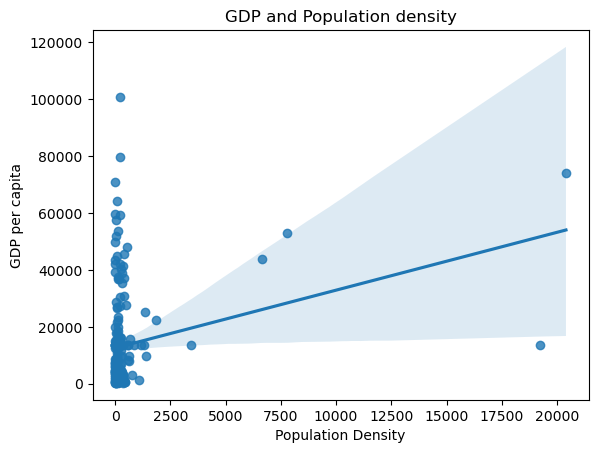

In [19]:
sns.regplot(x='Population density', y='GDP per capita', data=df)
plt.title('GDP and Population density')
plt.xlabel('Population Density')
plt.ylabel('GDP per capita')
plt.show()

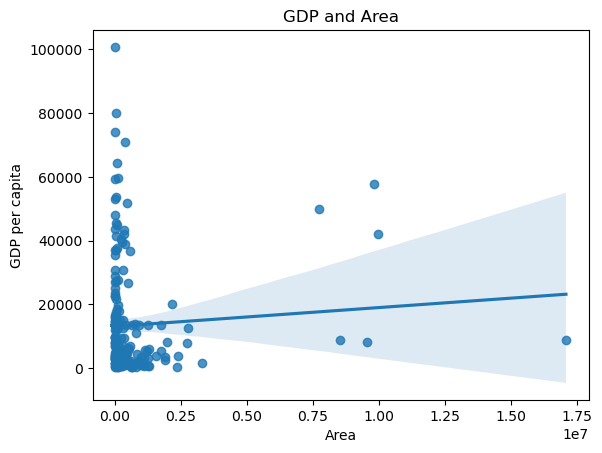

In [17]:
sns.regplot(x='Area', y='GDP per capita', data=df)
plt.title('GDP and Area')
plt.xlabel('Area')
plt.ylabel('GDP per capita')
plt.show()

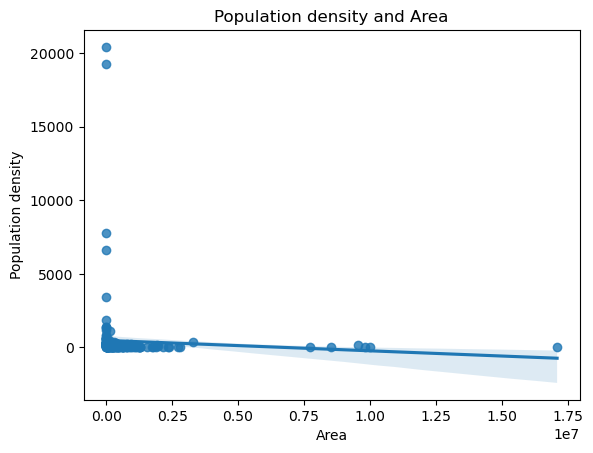

In [24]:
sns.regplot(x='Area', y='Population density', data=df)
plt.title('Population density and Area')
plt.xlabel('Area')
plt.ylabel('Population density')
plt.show()

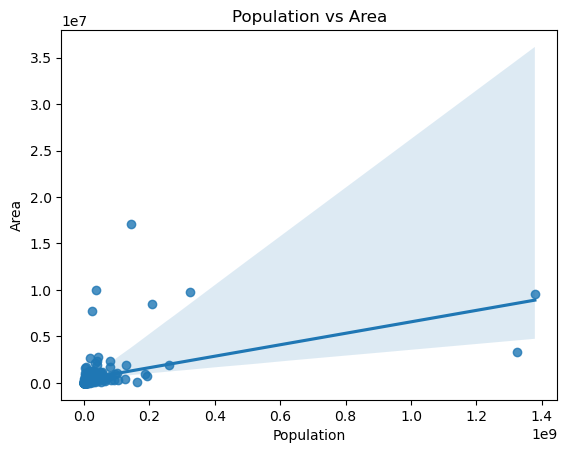

In [26]:
sns.regplot(x='Population', y='Area', data=df)
plt.title('Population vs Area')
plt.xlabel('Population')
plt.ylabel('Area')
plt.show()

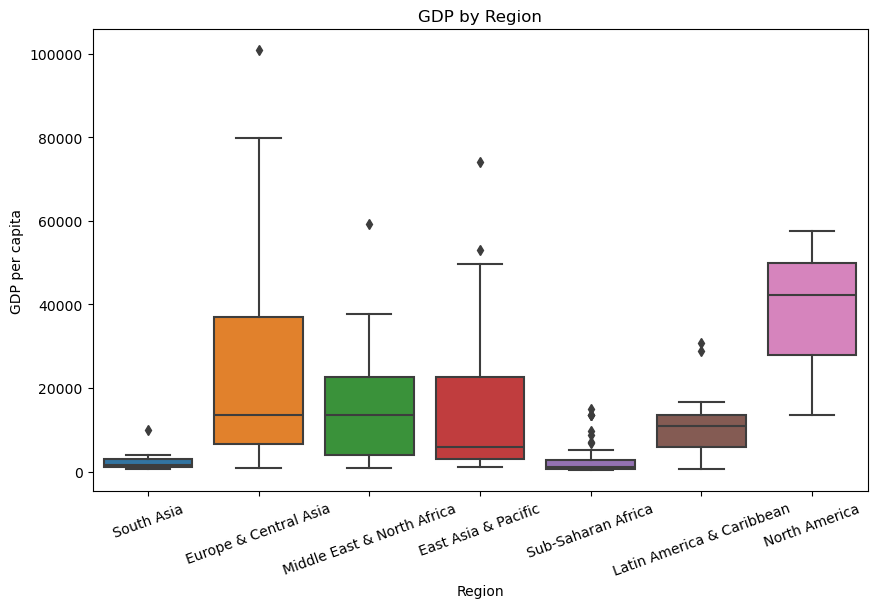

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Region', y='GDP per capita', data=df)
plt.title('GDP by Region')
plt.xticks(rotation=20)
plt.show()

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Порахувати кореляцію між всіма кількісними ознаками</p>
</div>


Рахую кореляцію між всіма кількісними ознаками

In [49]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns].corr()

,GDP per capita,Population,CO2 emission,Area,Population density
GDP per capita,1.000000,-0.047759,0.089094,0.063861,0.243727
Population,-0.047759,1.000000,0.802232,0.453500,-0.028438
CO2 emission,0.089094,0.802232,1.000000,0.585512,-0.017490
Area,0.063861,0.453500,0.585512,1.000000,-0.064006
Population density,0.243727,-0.028438,-0.017490,-0.064006,1.000000


<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Побудувати діаграму розмаху для 'CO2 emission' по регіонам. </p>
<p>Візуально оцініть наявність та силу зв'язку між цими ознаками.</p>
</div>


In [55]:
#для того, щоб визначити кількісні ознаки, переглянемо типи даних для кожної ознаки
df.dtypes

Country Name           object
Region                 object
GDP per capita        float64
Population            float64
CO2 emission          float64
Area                    int64
Population density    float64
dtype: object

Будую діаграму розсіювання для кількісних ознак та 'CO2 emission'

<Axes: xlabel='GDP per capita', ylabel='CO2 emission'>

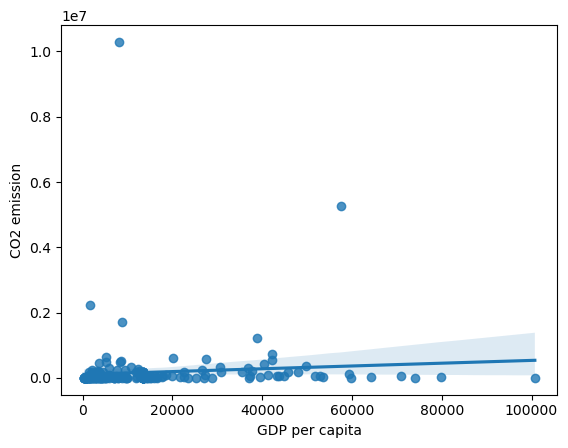

In [59]:
# GDP per capita and CO2 emission
sns.regplot(x='GDP per capita', y='CO2 emission', data=df)

Оскільки лінія регресії близька до горизонтальної, то GDP per capita не здається хорошим предиктором CO2 emission.

<Axes: xlabel='Population', ylabel='CO2 emission'>

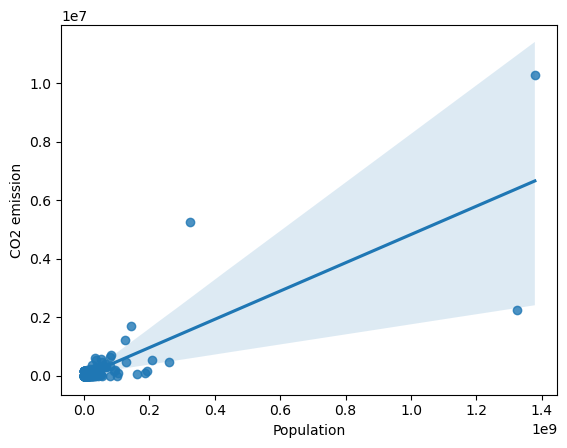

In [61]:
# Population and CO2 emission
sns.regplot(x='Population', y='CO2 emission', data=df)

Зі збільшенням Population збільшується і CO2 emission: це вказує на позитивну пряму кореляцію між цими двома ознаками (0.802232). Population здається досить хорошим предиктором для CO2 emission, оскільки лінія регресії є діагональною лінією.

<Axes: xlabel='Area', ylabel='CO2 emission'>

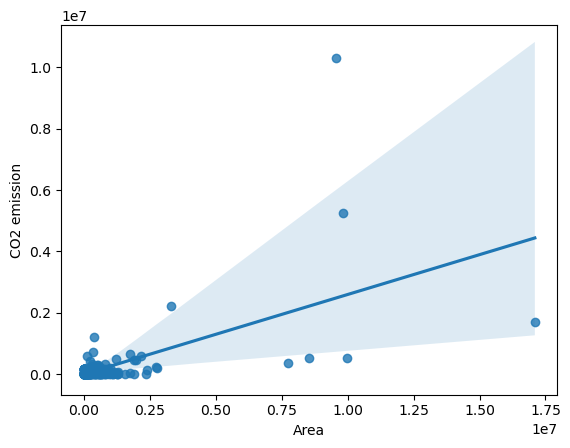

In [63]:
# Area and CO2 emission
sns.regplot(x='Area', y='CO2 emission', data=df)

Зі збільшенням Area збільшується і CO2 emission, тому Area можна вважати предиктором CO2 emission.

<Axes: xlabel='Population density', ylabel='CO2 emission'>

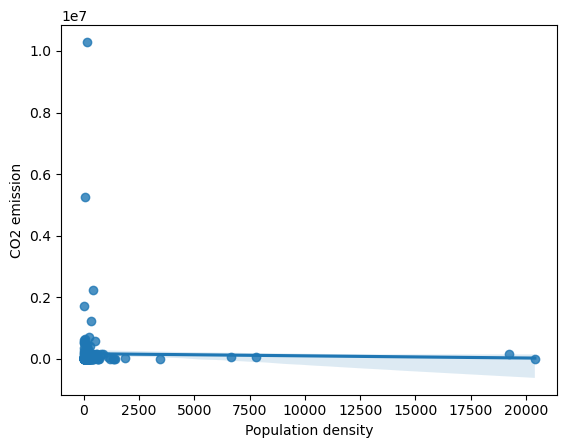

In [65]:
# Population density and CO2 emission
sns.regplot(x='Population density', y='CO2 emission', data=df)

Population densit не є хорошим предиктором для CO2 emission, оскільки лінія регресії близька до горизонтальної. 

Будую діаграму розмаху для 'CO2 emission' по регіонам

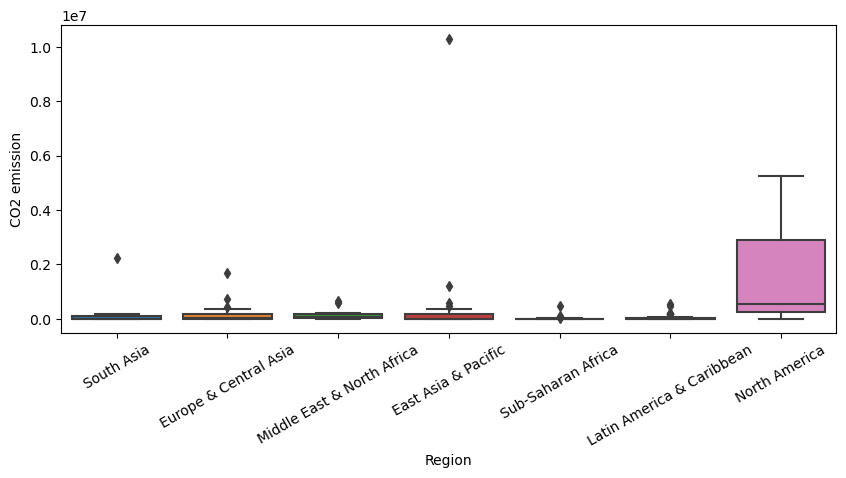

In [88]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
plt.figure(figsize=(10, 4))
sns.boxplot(x='Region', y='CO2 emission', data=df)
plt.xticks(rotation=30)
plt.show()

<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Які кількісні ознаки можуть бути предикторами кількості викидів СО2?</p>
</div>


Обчислюю коефіцієнт кореляції Пірсона та P-value для всіх кількісних змінних та 'CO2 emission'

GDP per capita та CO2 emission:

In [96]:
from scipy import stats

pearson_coef, p_value = stats.pearsonr(df['GDP per capita'], df['CO2 emission'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is 0.08909442180647846  with a P-value of P = 0.19105512270111463


Оскільки  p-value > 0.1, то кореляція між GDP per capita та CO2 emission не є значущою. Враховуючи, що коефіцієнт ~0.089, можна стверджувати, що ці дві змінні не впливають одна на одну, лінійний звʼязок майже відсутній. 

Population та CO2 emission:

In [111]:
pearson_coef, p_value = stats.pearsonr(df['Population'], df['CO2 emission'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is 0.8022315895757167  with a P-value of P = 4.63791802364356e-50


Оскільки  p-value < 0.001, кореляція між Population та CO2 emission є значущою. Лінійний зв’язок досить сильний (~0.802, близкий до 1).

Area та CO2 emission:

In [117]:
pearson_coef, p_value = stats.pearsonr(df['Area'], df['CO2 emission'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is 0.5855119221735575  with a P-value of P = 2.315747543725492e-21


Оскільки p-value < 0.001, кореляція між Area та CO2 emission є значущою. Лінійна залежність не дуже сильна (~0.586).

Population density та CO2 emission:

In [122]:
pearson_coef, p_value = stats.pearsonr(df['Population density'], df['CO2 emission'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

The Pearson Correlation Coefficient is -0.01749037974279751  with a P-value of P = 0.7978111739090935


Оскільки p-value > 0.1, то кореляція між Population density та CO2 emission не є значущою. Коефіцієнт близько -0.017 показує, що зв'язок негативний і майже відсутній.

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам</p>
</div>


Групую дані, щоб побачити чи впливає 'Region' на 'CO2 emission'.

In [133]:
region_grouped=df[['Region', 'CO2 emission']].groupby(['Region'])
region_grouped.head()

,Region,CO2 emission
0,South Asia,9.809225e+03
1,Europe & Central Asia,5.716853e+03
2,Middle East & North Africa,1.454002e+05
3,East Asia & Pacific,1.651141e+05
4,Europe & Central Asia,4.620420e+02
5,Sub-Saharan Africa,3.476316e+04
6,Latin America & Caribbean,5.317150e+02
7,Latin America & Caribbean,2.040245e+05
8,Europe & Central Asia,5.529836e+03
9,Latin America & Caribbean,8.727460e+02


Скористаюсь функцією <code>f_oneway</code> з модуля "stats" для отримання F-test score та P-value.

In [300]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('Europe & Central Asia')['CO2 emission'],
                              region_grouped.get_group('Middle East & North Africa')['CO2 emission'],
                              region_grouped.get_group('East Asia & Pacific')['CO2 emission'],
                              region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'],
                              region_grouped.get_group('Latin America & Caribbean')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 3.567709637673427 , P = 0.0021855506878927606


Результат із F = 3.57 показником тесту, який показує певну кореляцію, і P-value = 0.002 (< 0.05) показує, що обчислене значення F помірно значуще. Але чи означає це, що досліджувані групи корелюють між собою?

Розглянемо їх окремо.

1. South Asia, Europe & Central Asia

In [152]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('Europe & Central Asia')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 2.144988948953664 , P = 0.1479312427557026


P-value > 0.1 (~0.148), тобто обчислений F не є значущим.

2. South Asia, Middle East & North Africa

In [157]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('Middle East & North Africa')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 1.0781001825971537 , P = 0.3083326879268249


P-value > 0.1 (~0.308), тобто обчислений F не є значущим.

3. South Asia, East Asia & Pacific

In [163]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('East Asia & Pacific')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 0.01580888585558176 , P = 0.90052900845297


P-value > 0.1 (~0.9), тобто обчислений F не є значущим.

4. South Asia, Sub-Saharan Africa

In [167]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 7.300524087267293 , P = 0.009192711202178152


P-value < 0.05 (~0.009), тобто обчислений F є помірно значущим.

5. South Asia, Latin America & Caribbean

In [171]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('Latin America & Caribbean')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 4.454047216844206 , P = 0.04005521026835715


P-value < 0.05 (~0.04), тобто обчислений F є помірно значущим.

6. South Asia, North America

In [176]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('South Asia')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 2.4462636855311657 , P = 0.1522433374176963


P-value > 0.1 (~0.152), тобто обчислений F не є значущим.

7. Europe & Central Asia, Middle East & North Africa

In [180]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Europe & Central Asia')['CO2 emission'],
                              region_grouped.get_group('Middle East & North Africa')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 0.025434686706224285 , P = 0.8737062957355305


P-value > 0.1 (~0.874), тобто обчислений F не є значущим.

8. Europe & Central Asia, East Asia & Pacific

In [191]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Europe & Central Asia')['CO2 emission'],
                              region_grouped.get_group('East Asia & Pacific')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 1.442513589456402 , P = 0.23278299644117575


P-value > 0.1 (~0.232), тобто обчислений F не є значущим.

9. Europe & Central Asia, Sub-Saharan Africa

In [188]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Europe & Central Asia')['CO2 emission'],
                              region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 7.930055837622809 , P = 0.0058179788422628425


P-value < 0.05 (~0,006), тобто обчислений F є помірно значущим.

10. Europe & Central Asia, Latin America & Caribbean

In [195]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Europe & Central Asia')['CO2 emission'],
                              region_grouped.get_group('Latin America & Caribbean')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 2.456104756327821 , P = 0.12029220254983183


P-value > 0.1 (~0.12), тобто обчислений F не є значущим.

11. Europe & Central Asia, North America

In [199]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Europe & Central Asia')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 27.185776372971752 , P = 2.4871297063504576e-06


P-value < 0.001, тобто обчислений F є значущим.

12. Middle East & North Africa, East Asia & Pacific

In [203]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Middle East & North Africa')['CO2 emission'],
                              region_grouped.get_group('East Asia & Pacific')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 0.49326851648527353 , P = 0.48538208348892753


P-value > 0.1 (~0.485), тобто обчислений F не є значущим.

13. Middle East & North Africa, Sub-Saharan Africa

In [207]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Middle East & North Africa')['CO2 emission'],
                              region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 14.816051348200512 , P = 0.00026718681820385405


P-value < 0.001, тобто обчислений F є значущим.

14. Middle East & North Africa, Latin America & Caribbean

In [211]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Middle East & North Africa')['CO2 emission'],
                              region_grouped.get_group('Latin America & Caribbean')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 4.000283765765509 , P = 0.04995035790485582


P-value < 0.05 (~0,049995), тобто обчислений F є помірно значущим.

15. Middle East & North Africa, North America

In [215]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Middle East & North Africa')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 10.785908142809197 , P = 0.003386665615272284


P-value < 0.05 (~0,003), тобто обчислений F є помірно значущим.

16. East Asia & Pacific, Sub-Saharan Africa

In [219]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('East Asia & Pacific')['CO2 emission'],
                              region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 2.3674674670688405 , P = 0.12769170648670677


P-value > 0.1 (~0.128), тобто обчислений F не є значущим.

17. East Asia & Pacific, Latin America & Caribbean

In [223]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('East Asia & Pacific')['CO2 emission'],
                              region_grouped.get_group('Latin America & Caribbean')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 1.6466960216456292 , P = 0.20325802138349316


P-value > 0.1 (~0.203), тобто обчислений F не є значущим.

18. East Asia & Pacific, North America

In [227]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('East Asia & Pacific')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 2.0911315955888354 , P = 0.1563544185723686


P-value > 0.1 (~0.156), тобто обчислений F не є значущим.

19. Sub-Saharan Africa, Latin America & Caribbean

In [231]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'],
                              region_grouped.get_group('Latin America & Caribbean')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 3.924375647081417 , P = 0.05071332517066325


P-value < 0.1 (~0.051), тобто є слабкі докази того, що кореляція є значною.

20. Sub-Saharan Africa, North America

In [235]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Sub-Saharan Africa')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 29.889184991922956 , P = 1.5319132629213873e-06


P-value < 0.001, тобто обчислений F є значущим.

21. Latin America & Caribbean, North America

In [239]:
f_val, p_val = stats.f_oneway(region_grouped.get_group('Latin America & Caribbean')['CO2 emission'],
                              region_grouped.get_group('North America')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 24.47756779640105 , P = 1.2020263394688284e-05


P-value < 0.001, тобто обчислений F є значущим.

Висновок.

Регіони, в яких наявні вагомі докази того, що кореляція є значною (P-value < 0.001):
* Latin America & Caribbean, North America
* Sub-Saharan Africa, North America
* Middle East & North Africa, Sub-Saharan Africa
* Europe & Central Asia, North America

<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.
2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.
3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.

Sub-Saharan Africa, North America. P-value < 0.001, тобто обчислений F = 29.889 є значущим.

2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.

In [263]:
pd.set_option('display.precision', 2)

intervals = np.linspace(min(df['GDP per capita']), max(df['GDP per capita']), 6)
groups = ['low income', 'below average income', 'average income', 'above average income', 'high income']
df['Rich country'] = pd.cut(df['GDP per capita'], intervals, labels=groups)
df[['GDP per capita', 'Rich country']]

,GDP per capita,Rich country
0,561.78,low income
1,4124.98,low income
2,3916.88,low income
3,11834.75,low income
4,36988.62,below average income
...,...,...
212,13445.59,low income
213,2943.40,low income
214,990.33,low income
215,1269.57,low income


Побудуємо діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


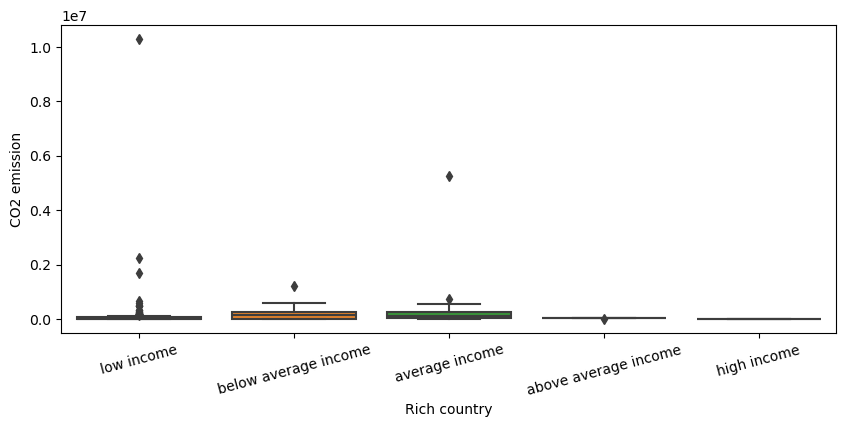

In [290]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='Rich country', y='CO2 emission', data=df)
plt.xticks(rotation=15)
plt.show()

Бачимо, що розподіл CO2 emission між різними категоріями країн за доходом значно збігається, тому Rich country не буде хорошим показником CO2 emission.

In [295]:
df['Rich country'].value_counts()

Rich country
low income              176
below average income     20
average income           15
above average income      4
high income               1
Name: count, dtype: int64

<details><summary>Натисніть тут, щоб побачити підказку</summary>

Групування кількісної змінної в категорії було в попередній лабораторній роботі. Використайте функцію "cut"
</details>

3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

In [308]:
income_grouped=df[['Rich country', 'CO2 emission']].groupby(['Rich country'], observed=False)

f_val, p_val = stats.f_oneway(income_grouped.get_group('low income')['CO2 emission'],
                              income_grouped.get_group('below average income')['CO2 emission'],
                              income_grouped.get_group('average income')['CO2 emission'],
                              income_grouped.get_group('above average income')['CO2 emission'],
                              income_grouped.get_group('high income')['CO2 emission'])
print( "ANOVA results: F=", f_val, ", P =", p_val)

ANOVA results: F= 0.7885604538341517 , P = 0.5337485074075127


P-value > 0.1 (~0.534), тобто обчислений F не є значущим.

<h2>Виконав студент групи ІП-23 <br> Матвієнко Дарʼя</h2>